# Problem 3 - State Estimation

## Agenda
- Problem Description
- Problem Implementation
- Alternative Problems
- Wrap-Up

## Problem Description
- <b>Consider a grid for which we have sufficient metering data <i>z<sub>meter</sub></i> and discover the state vector <i>x</i> that fully characterizes the condition in which the grid is being operated, given the grid static information of its structure and corresponding component models.<b>

    _______________________________________________________________________________________________________________________

Considered "Kite" 5 Bus Network
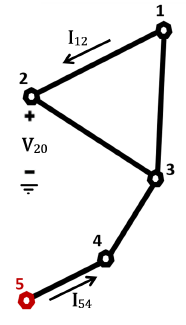

- <b>Implementation.<b>

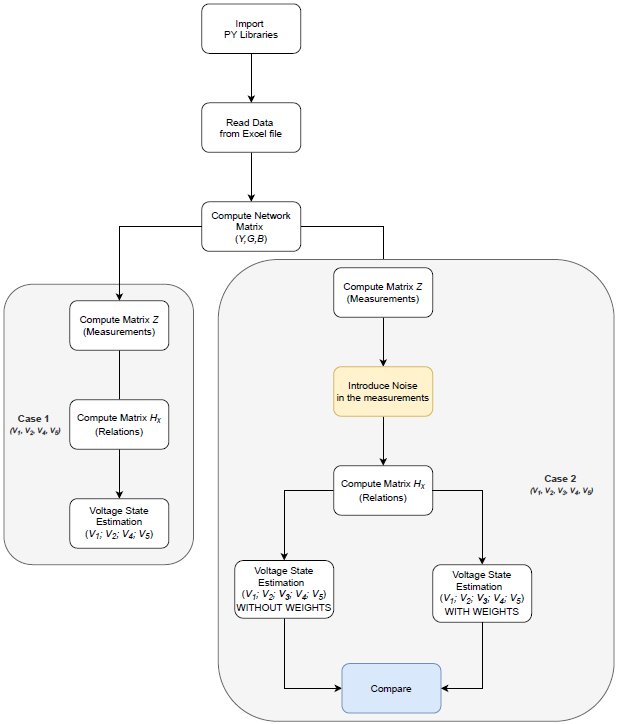

<b>Import Python Libraries

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

<b>Parameters

In [51]:
networkFactor = 100    # To change the characteristics of the network (Y)
cosPhi=0.95            # Value of teta
m=100                  # Number of Iterations   
sig=0.5                # Noise factor 

<b>Import data (From Excel file)

In [52]:
Info = np.array(pd.read_excel (r'DASG_Prob2_new.xlsx', sheet_name='Info', header=None))
# Information about the slack bus
SlackBus=Info[0,1]
print ("Slack Bus: ", SlackBus,"\n")

# Network Information
Net_Info = np.array(pd.read_excel (r'DASG_Prob2_new.xlsx', sheet_name='Y_Data'))
print ("Lines information (Admitances)\n", Net_Info, "\n")

#Power Information (train)
Power_Info = np.array(pd.read_excel (r'DASG_Prob2_new.xlsx', sheet_name='Load(t,Bus)'))
Power_Info = np.delete(Power_Info,[0],1)
print ("Power consumption information (time, Bus) - (Train)\n", Power_Info, "\n")

time=Power_Info.shape[0]
P=np.dot(-Power_Info,np.exp(complex(0,1)*np.arccos(cosPhi)))
I=np.conj(P[2,:])

Slack Bus:  5 

Lines information (Admitances)
 [[1 2 '0,01-0,1i']
 [1 3 '0,02-0,2i']
 [2 3 '0,03-0,2i']
 [3 4 '0,03-0,2i']
 [4 5 '0,02-0,2i']] 

Power consumption information (time, Bus) - (Train)
 [[0.332 0.064 0.084 0.12 ]
 [0.236 0.164 0.276 0.064]
 [0.224 0.708 1.572 0.072]
 [0.36  3.44  1.188 0.18 ]
 [1.332 2.176 0.484 1.464]
 [1.516 3.02  0.316 0.624]
 [0.92  0.916 0.404 2.772]
 [0.752 0.64  0.396 1.464]
 [1.828 0.684 0.576 0.576]
 [3.568 0.564 0.828 0.428]
 [0.78  0.356 0.728 0.348]
 [0.856 0.22  0.308 0.12 ]
 [0.684 0.528 0.256 0.44 ]] 



<b>Admittance Matrix(Y); Conductance Matrix(G); Susceptance Matrix(B)

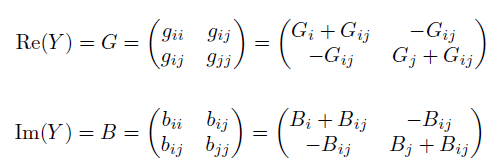

In [53]:
# Determine the number of Bus
nBus=max(np.max(Net_Info[:,0]),np.max(Net_Info[:,1]))

# Create the variable number of lines and the admitance matrix (Y)
nLines=Net_Info.shape[0]

Y=np.zeros((nBus,nBus), dtype=complex)

#Complete the Y matrix nad update the number of lines
for i in range (Net_Info.shape[0]):
    y_aux=Net_Info[i,2].replace(",",".")
    y_aux=y_aux.replace("i","j")
    Y[Net_Info[i,0]-1,Net_Info[i,0]-1]=Y[Net_Info[i,0]-1,Net_Info[i,0]-1]+complex(y_aux)*networkFactor
    Y[Net_Info[i,1]-1,Net_Info[i,1]-1]=Y[Net_Info[i,1]-1,Net_Info[i,1]-1]+complex(y_aux)*networkFactor
    Y[Net_Info[i,0]-1,Net_Info[i,1]-1]=Y[Net_Info[i,0]-1,Net_Info[i,1]-1]-complex(y_aux)*networkFactor
    Y[Net_Info[i,1]-1,Net_Info[i,0]-1]=Y[Net_Info[i,1]-1,Net_Info[i,0]-1]-complex(y_aux)*networkFactor

            
# Remove the slack bus from the admitance matrix            
Yl=np.delete(Y, np.s_[SlackBus-1], axis=0)
Yl=np.delete(Yl, np.s_[SlackBus-1], axis=1)

# Conductance Matrix
G=Yl.real

# Susceptance Matrix
B=Yl.imag 

print("The admitance matrix Y is:\n", Y, "\n")
print("The conductance matrix G is\n", G, "\n")
print("The susceptance matrix B is\n",B, "\n")

The admitance matrix Y is:
 [[ 3.-30.j -1.+10.j -2.+20.j  0. +0.j  0. +0.j]
 [-1.+10.j  4.-30.j -3.+20.j  0. +0.j  0. +0.j]
 [-2.+20.j -3.+20.j  8.-60.j -3.+20.j  0. +0.j]
 [ 0. +0.j  0. +0.j -3.+20.j  5.-40.j -2.+20.j]
 [ 0. +0.j  0. +0.j  0. +0.j -2.+20.j  2.-20.j]] 

The conductance matrix G is
 [[ 3. -1. -2.  0.]
 [-1.  4. -3.  0.]
 [-2. -3.  8. -3.]
 [ 0.  0. -3.  5.]] 

The susceptance matrix B is
 [[-30.  10.  20.   0.]
 [ 10. -30.  20.   0.]
 [ 20.  20. -60.  20.]
 [  0.   0.  20. -40.]] 



<b>1º State Estimation considering complete information about currents <i>I<sub>12</sub></i> and <i>I<sub>54</sub></i> (amplitude and angle) and not estimating <i>V<sub>3</sub></i>; Page 39

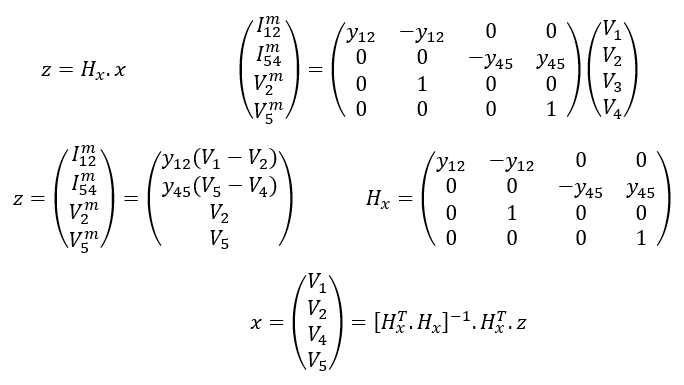

In [54]:
# Matrix Creation
b0s=np.zeros((4), dtype=complex)
A0s=np.zeros((4,4), dtype=complex)
v0s=np.zeros((5), dtype=complex)

# Voltage Computing (Reference)
v_points = ["V1", "V2", "V3", "V4", "V5"]

v0s[0:4]=1+np.dot(np.linalg.inv(Yl),I)
v0s[4]=1

print("The voltage values v are:")
for i in range(len(v0s)):
    print(f"{v_points[i]}: {v0s[i]}")

# Measurement values z 
z0s=np.zeros((4), dtype=complex)
z0_measurements = ["I12m", "I54m", "V2m", "V5m"]

y12 = -Y[0,1]
y45 = -Y[3,4]

z0s[0] = y12*(v0s[0]-v0s[1])
z0s[1] = y45*(v0s[4]-v0s[3])
z0s[2] = v0s[1]
z0s[3] = v0s[4]

z0s_show = np.round(z0s, 4)

print("\nThe measurement values z are:")
for i in range(len(z0s)):
    print(f"{z0_measurements[i]}: {z0s_show[i]}")

# Matrix Hx 
Hx0s=np.zeros((4,4), dtype=complex)
Hx0s[0,0] = y12
Hx0s[0,1] = -y12
Hx0s[1,2] = -y45
Hx0s[1,3] = y45
Hx0s[2,1] = 1
Hx0s[3,3] = 1

# print matrix Hx, but if 0, print 0 instead of 0+ 0j
print("\nThe matrix Hx is:", Hx0s, "\n")

#State Variables (x) - These variables are the estimated voltages (V1; V2; V4; V5)
x0=np.zeros((4), dtype=complex)
x_states = ["V1", "V2", "V4", "V5"]

# Least squares estimation of the voltages without noise
x0=np.dot(np.linalg.inv(Hx0s.T.dot(Hx0s)),Hx0s.T.dot(z0s))

x0_show = np.round(x0, 4)

print("The estimated voltages are:")
for i in range(len(x0)):
    print(f"{x_states[i]}: {x0_show[i]}")


The voltage values v are:
V1: (0.8851206231406004-0.24325600517058865j)
V2: (0.8796265236486482-0.25388266552809124j)
V3: (0.892383711380738-0.2277542788412536j)
V4: (0.9480655573171428-0.11716655573171429j)
V5: (1+0j)

The measurement values z are:
I12m: (0.1118-0.0443j)
I54m: (2.4472-0.8044j)
V2m: (0.8796-0.2539j)
V5m: (1+0j)

The matrix Hx is: [[ 1.-10.j -1.+10.j  0. +0.j  0. +0.j]
 [ 0. +0.j  0. +0.j -2.+20.j  2.-20.j]
 [ 0. +0.j  1. +0.j  0. +0.j  0. +0.j]
 [ 0. +0.j  0. +0.j  0. +0.j  1. +0.j]] 

The estimated voltages are:
V1: (0.8851-0.2433j)
V2: (0.8796-0.2539j)
V4: (0.9481-0.1172j)
V5: (1-0j)


<b>2º State Estimation considering rms1111 information of currents <i>I<sub>12</sub></i> and <i>I<sub>54</sub></i> and estimating <i>V<sub>3</sub></i>. Page 41
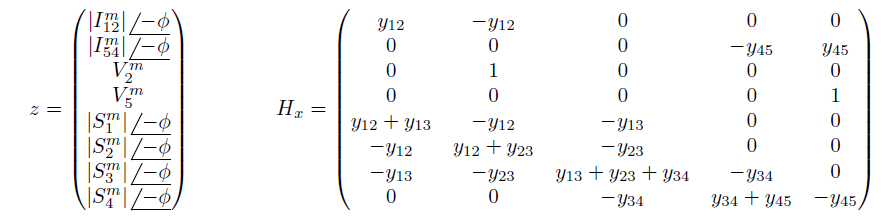

In [55]:
# Matrix Creation
b0=np.zeros((8), dtype=complex)
b1=np.zeros((8), dtype=complex)
b2=np.zeros((8), dtype=complex)
A=np.zeros((8,5), dtype=complex)
v=np.zeros((5), dtype=complex)

# line admitances
y12 = -Y[0,1]
y13 = -Y[0,2]
y23 = -Y[1,2]
y34 = -Y[2,3]
y45 = -Y[3,4]

# print line admitances
print(f"y12: {y12}")
print(f"y13: {y13}")
print(f"y23: {y23}")
print(f"y34: {y34}")
print(f"y45: {y45}")

# Voltage Computing (Reference)
v[0:4]=1+np.dot(np.linalg.inv(Yl),I)
v[4]=1

# Measurement values z (In that case, we are computing the currents and voltages but we can also measure them).
b0[0]=np.dot(np.absolute(np.dot(-Y[0,1],(v[0]-v[1]))),np.exp(complex(0,-1)*np.arccos(cosPhi)))
b0[1]=np.dot(np.absolute(np.dot(-Y[3,4],(1-v[3]))),np.exp(complex(0,-1)*np.arccos(cosPhi)))
b0[2]=v[1]
b0[3]=1
b0[4:8]=I #In that case, we are also including the vectors of aparent power

z_measurements = ["I12m", "I54m", "V2m", "V5m", "I1m", "I2m", "I3m", "I4m"]
for i in range(len(b0)):
    print(f"{z_measurements[i]}: {b0[i]}")

# Matrix Hx (Page 41)´
Hx=np.zeros((8,5), dtype=complex)
# I12
Hx[0,0] = y12
Hx[0,1] = -y12
# I54
Hx[1,3] = -y45
Hx[1,4] = y45
# V2
Hx[2,1] = 1
# V5
Hx[3,4] = 1
# I1
Hx[4,0] = y12 + y13
Hx[4,1] = -y12
Hx[4,2] = -y13
# I2
Hx[5,0] = -y12
Hx[5,1] = y12 + y23
Hx[5,2] = -y23
# I3
Hx[6,0] = -y13
Hx[6,1] = -y23
Hx[6,2] = y13 + y23 + y34
Hx[6,3] = -y34

# I4
Hx[7,2] = -y34
Hx[7,3] = y34 + y45
Hx[7,4] = -y45

print("\nThe matrix Hx is:\n", Hx, "\n")


y12: (1-10j)
y13: (2-20j)
y23: (3-20j)
y34: (3-20j)
y45: (2-20j)
I12m: (0.11421439942241969-0.037540457672699284j)
I54m: (2.4472000000000005-0.8043557421937142j)
V2m: (0.8796265236486482-0.25388266552809124j)
V5m: (1+0j)
I1m: (-0.2128+0.06994397758206208j)
I2m: (-0.6726+0.22107292914330337j)
I3m: (-1.4934+0.4908568426741143j)
I4m: (-0.06839999999999999+0.02248199279423424j)

The matrix Hx is:
 [[ 1.-10.j -1.+10.j  0. +0.j  0. +0.j  0. +0.j]
 [ 0. +0.j  0. +0.j  0. +0.j -2.+20.j  2.-20.j]
 [ 0. +0.j  1. +0.j  0. +0.j  0. +0.j  0. +0.j]
 [ 0. +0.j  0. +0.j  0. +0.j  0. +0.j  1. +0.j]
 [ 3.-30.j -1.+10.j -2.+20.j  0. +0.j  0. +0.j]
 [-1.+10.j  4.-30.j -3.+20.j  0. +0.j  0. +0.j]
 [-2.+20.j -3.+20.j  8.-60.j -3.+20.j  0. +0.j]
 [ 0. +0.j  0. +0.j -3.+20.j  5.-40.j -2.+20.j]] 



<b>2º a) - First, the weight of pseudo-measurements (Matrix W) <u>are not considered</u>;

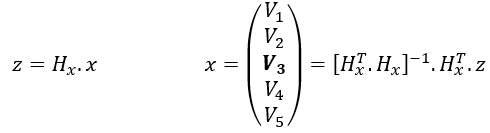

The estimated voltages without noise are:
V1: (0.8851-0.2432j)
V2: (0.8796-0.2539j)
V3: (0.8924-0.2277j)
V4: (0.948-0.1172j)
V5: (1+0j)


C:\Users\ASUS\AppData\Local\Temp\ipykernel_13884\3854568404.py:38: ComplexWarning: Casting complex values to real discards the imaginary part
  rms1[:,i]=np.sqrt(np.dot((x1_noise-x1),np.conjugate(x1_noise-x1)))


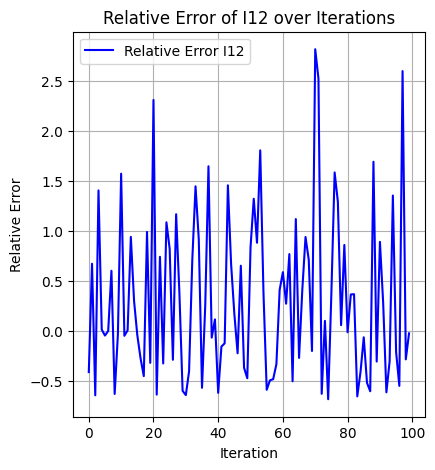


The average estimated voltages over all iterations are: 
V1: (0.882-0.2485j)
V2: (0.8768-0.2565j)
V3: (0.8895-0.2312j)
V4: (0.9458-0.1162j)
V5: (0.9979+0.0026j)

The average rms1 error for each voltage is:
V1: 0.14542166522924552
V2: 0.14542166522924552
V3: 0.14542166522924552
V4: 0.14542166522924552
V5: 0.14542166522924552


In [ ]:
# sig = 0.5
#Noise to be added to measurements
sig_m = sig / 5
e_m = np.random.normal(0.0, 1.0, size=(4,m)) * sig_m
#Noise to be added to peseudo-measurements
sig_pm = sig
e_pm = np.random.normal(0.0, 1.0, size=(4,m)) * sig_pm

#Estimation not considering the noise 
x1_states = ["V1", "V2", "V3", "V4", "V5"]
# Least squares estimation of the voltages without noise
x1 = np.dot(np.linalg.inv(Hx.T.dot(Hx)),Hx.T.dot(b0))

x1_show = np.round(x1, 4)

print("The estimated voltages without noise are:")
for i in range(len(x1)):
    print(f"{x1_states[i]}: {x1_show[i]}")
    
#Matrix creation 
sx1=np.zeros(5)
rms1=np.zeros((5,m))
ei12a1=np.zeros(m)
ei54a1=np.zeros(m)

for i in range(m):
    #Introduce error in the measurements (Matrix z)
    b1[0:4]=b0[0:4]+e_m[:,i]
    b1[4:8]=I+e_pm[:,i]   
    
    #Estimate the voltages based on measurements with the errors
    x1_noise=np.dot(np.linalg.inv(Hx.T.dot(Hx)),Hx.T.dot(b1))
    
    #Accumulated value of estimations
    sx1=sx1+x1_noise
    
    #Errors in the voltages
    rms1[:,i]=np.sqrt(np.dot((x1_noise-x1),np.conjugate(x1_noise-x1))) 
    
    # x1 is the initial estimation not considering the noise 
    # x1_noise is the estimation considering the noise 

    # Relative current errors (To be used in the graphics)
    ei12a1[i]=np.divide(np.absolute(np.dot(Y[0,1],(x1_noise[0]-x1_noise[1])))-np.absolute(np.dot(Y[0,1],(v[0]-v[1]))),np.absolute(np.dot(Y[0,1],(v[0]-v[1]))))
    ei54a1[i]=np.divide(np.absolute(np.dot(Y[3,4],(1-x1_noise[3])))-np.absolute(np.dot(Y[3,4],(1-v[3]))),np.absolute(np.dot(Y[3,4],(1-v[3]))))

#Average Voltage Estimation
x_avg1=sx1/m

x_avg1_show = np.round(x_avg1, 4)

print("\nThe average estimated voltages over all iterations are: ")
for i in range(len(x_avg1)):
    print(f"{x1_states[i]}: {x_avg1_show[i]}")

#Average Voltage rms1 Error
ee1=np.transpose(np.matrix,sum(np.transpose(rms1)))/m

print("\nThe average rms1 error for each voltage is:")
for i in range(len(ee1)):
    print(f"{x1_states[i]}: {ee1[i]}")



<b>2º b) - Second, the weight of pseudo-measurements (Matrix W) <u>are considered</u>;
    
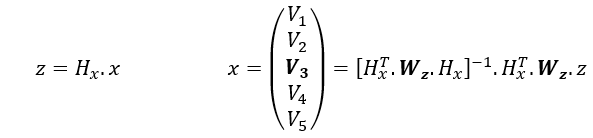

In [57]:
# The vector of errors is the same used in the first scenario 

#Matriz of the Weights (W)
#Matriz of the Weights (W)

# Define the matrix W with the appropriate dimensions
W = np.zeros((8, 8))
np.fill_diagonal(W[0:4], sig_m**-2)
np.fill_diagonal(W[4:8,4:8], sig_pm**-2)

# print da matriz W
round_W = np.round(W, 4)
print("\nThe matrix W is:")
for i in range(W.shape[0]):
    for j in range(W.shape[1]):
        if round_W[i,j] == 0:
            print("0", end=" ")
        else:
            print(round_W[i,j], end=" ")
    print()  # New line after each row

#Estimation not considering the noise, but considering the weight 
x2 = np.dot(np.linalg.inv(Hx.T.dot(W).dot(Hx)),Hx.T.dot(W).dot(b0))

x2_show=np.round(x2, 4)

print("\nEstimated voltages considering the weights:")
for i in range(len(x2)):
    print(f"V{i+1}: {x2_show[i]}")

#Matrix creation 
sx2=np.zeros(5)
rms2=np.zeros((5,m))
ei12a2=np.zeros(m)
ei54a2=np.zeros(m)

for i in range(m):
    #Introduce error in the measurements (Matrix z) 

    #Estimate the voltages based on measurements with the errors
    x2_noise=np.dot(np.linalg.inv(Hx.T.dot(W).dot(Hx)),Hx.T.dot(W).dot(b1))

    #Accumulated value of estimations
    sx2=sx2+x2_noise

    #Errors in the voltages
    rms2[:,i]=np.sqrt(np.dot((x2_noise-x2),np.conjugate(x2_noise-x2)))

    #Relative current errors (To be used in the graphics)
    ei12a2[i]=np.divide(np.absolute(np.dot(Y[0,1],(x2_noise[0]-x2_noise[1])))-np.absolute(np.dot(Y[0,1],(v[0]-v[1]))),np.absolute(np.dot(Y[0,1],(v[0]-v[1]))))
    ei54a2[i]=np.divide(np.absolute(np.dot(Y[3,4],(1-x2_noise[3])))-np.absolute(np.dot(Y[3,4],(1-v[3]))),np.absolute(np.dot(Y[3,4],(1-v[3]))))
    
#Average Voltage Estimation
x_avg2=sx2/m

x_avg2_show = np.round(x_avg2, 4)

print("\nThe average estimated voltages over all iterations are: ")
for i in range(len(x_avg2)):
    print(f"{x1_states[i]}: {x_avg2_show[i]}")

#Average Voltage rms2 Error
ee2=np.transpose(np.matrix,sum(np.transpose(rms2)))/m

print("\nThe average rms2 error for each voltage is:")
for i in range(len(ee2)):
    print(f"{x1_states[i]}: {ee2[i]}")



The matrix W is:
1000000.0 0 0 0 0 0 0 0 
0 1000000.0 0 0 0 0 0 0 
0 0 1000000.0 0 0 0 0 0 
0 0 0 1000000.0 0 0 0 0 
0 0 0 0 4.0 0 0 0 
0 0 0 0 0 4.0 0 0 
0 0 0 0 0 0 4.0 0 
0 0 0 0 0 0 0 4.0 

Estimated voltages considering the weights:
V1: (0.8845-0.2429j)
V2: (0.8796-0.2539j)
V3: (0.8922-0.2276j)
V4: (0.9481-0.1172j)
V5: (1-0j)

The average estimated voltages over all iterations are: 
V1: (0.8839-0.2428j)
V2: (0.8791-0.2539j)
V3: (0.8916-0.2309j)
V4: (0.9489-0.1172j)
V5: (1.0008+0j)

The average rms2 error for each voltage is:
V1: 0.0035353035996957467
V2: 0.0035353035996957467
V3: 0.0035353035996957467
V4: 0.0035353035996957467
V5: 0.0035353035996957467


C:\Users\ASUS\AppData\Local\Temp\ipykernel_13884\3903324352.py:47: ComplexWarning: Casting complex values to real discards the imaginary part
  rms2[:,i]=np.sqrt(np.dot((x2_noise-x2),np.conjugate(x2_noise-x2)))


<b>Plot Results

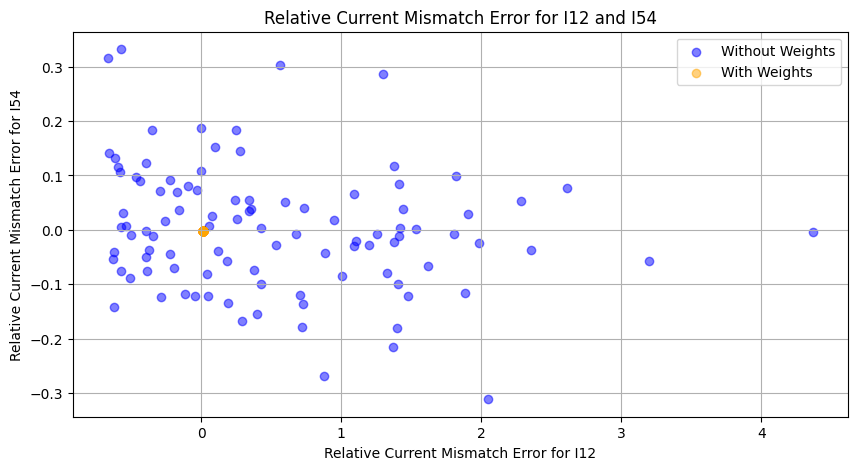

In [58]:
# Current mismatch error graphics

# Plot of relative current mismatch error for I12 and I54 scatter plot
plt.figure(figsize=(10, 5))
plt.scatter(ei12a1, ei54a1, color='blue', label='Without Weights', alpha=0.5)
plt.scatter(ei12a2, ei54a2, color='orange', label='With Weights', alpha=0.5)
plt.title('Relative Current Mismatch Error for I12 and I54')
plt.xlabel('Relative Current Mismatch Error for I12')
plt.ylabel('Relative Current Mismatch Error for I54')
plt.legend()
plt.grid()
plt.show()


# Extra Project Goals
Think about an interesting variation to this problem or a different way to solve and implement it !!!

Some ideas:
- Assume you have to chose just two out of four possible pseudo-measurements, S<sup>m</sup><sub>1</sub> , S<sup>m</sup><sub>2</sub> , S<sup>m</sup><sub>3</sub> , S<sup>m</sup><sub>4</sub> . What would be your choices and why? Chose based on probable accuracy of the resulting estimation.
- Assume that <i>I<sub>12</sub>=0</i>. Under this assumption, one of two possible situations may be occuring: either branch 1-2 is out of service (<i>y<sub>12</sub>=0</i>) or the corresponding current meter is malfunctioning. Decide about the most probable situation based on the accuracy of the corresponding estimation. as in the previous exercice, use the matrix <i>R<sub>x</sub></i> andd consider different matrices <i>W<sub>z</sub></i> including the identity matrix. Elaborate on the effects of <i>W<sub>z</sub></i>.  
